In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala import graph_utils as gu
from koala import plotting as pl

from koala import example_graphs as eg
from koala.lattice import Lattice, _sorted_vertex_adjacent_edges

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

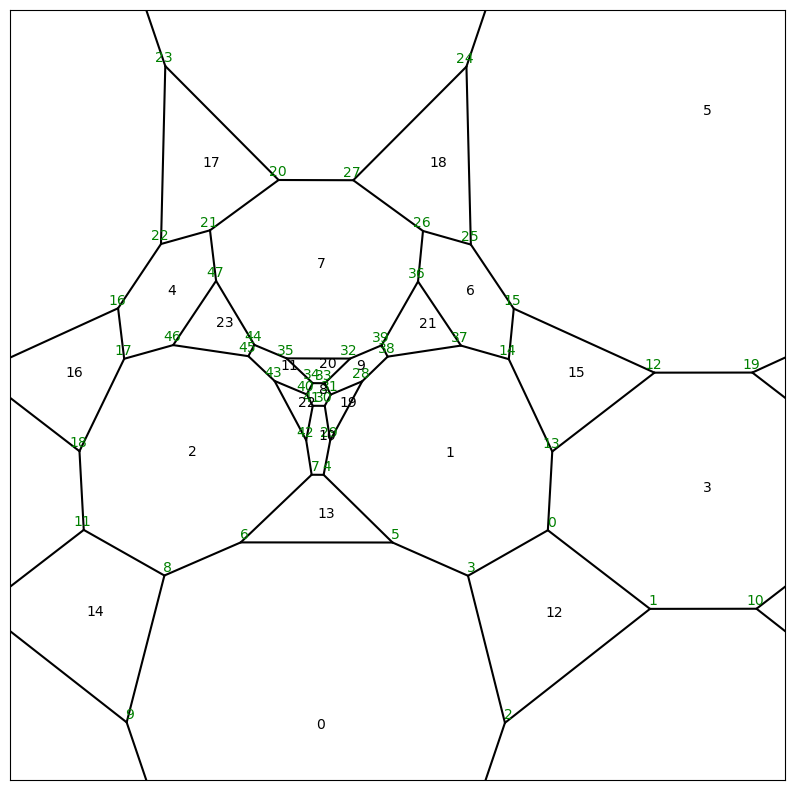

In [45]:
# generate a bipartite lattice
n_sites = 50

lattice = generate_lattice(uniform(n_sites // 4))
dimerisation = gu.dimerise(lattice)
lattice = gu.dimer_collapse(lattice, dimerisation)
lattice = gu.vertices_to_polygon(lattice)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
pl.plot_edges(lattice)
pl.plot_vertex_indices(lattice, color="g")
pl.plot_plaquette_indices(lattice)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

Text(0.5, 1.0, 'Flipped and relaxed')

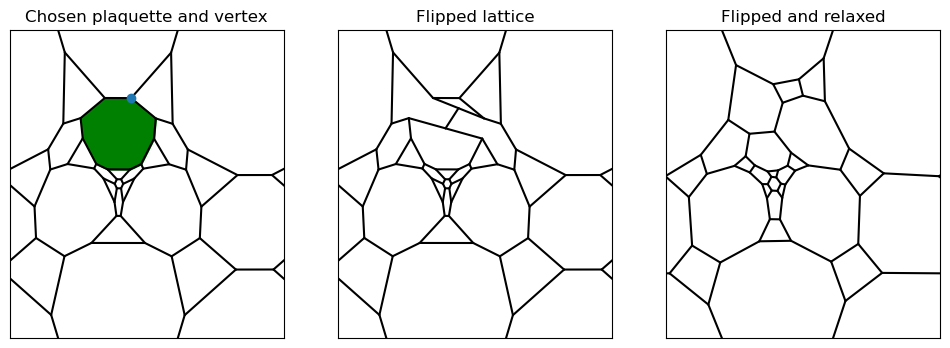

In [46]:
from koala.pachner_moves import bipartite_1_plus

# find a non-square:
p = 7
v = lattice.plaquettes[p].vertices[0]

l1plus = bipartite_1_plus(lattice, p, v)
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])

pl.plot_edges(lattice, ax=ax[0])
pl.plot_plaquettes(lattice, ax=ax[0], subset=[p], color_scheme="green")
ax[0].scatter(*lattice.vertices.positions[v], zorder=10)

pl.plot_edges(l1plus, ax=ax[1])
pl.plot_edges(gu.com_relaxation(l1plus), ax=ax[2])

ax[0].set_title("Chosen plaquette and vertex")
ax[1].set_title("Flipped lattice")
ax[2].set_title("Flipped and relaxed")

Text(0.5, 1.0, 'Flipped and relaxed')

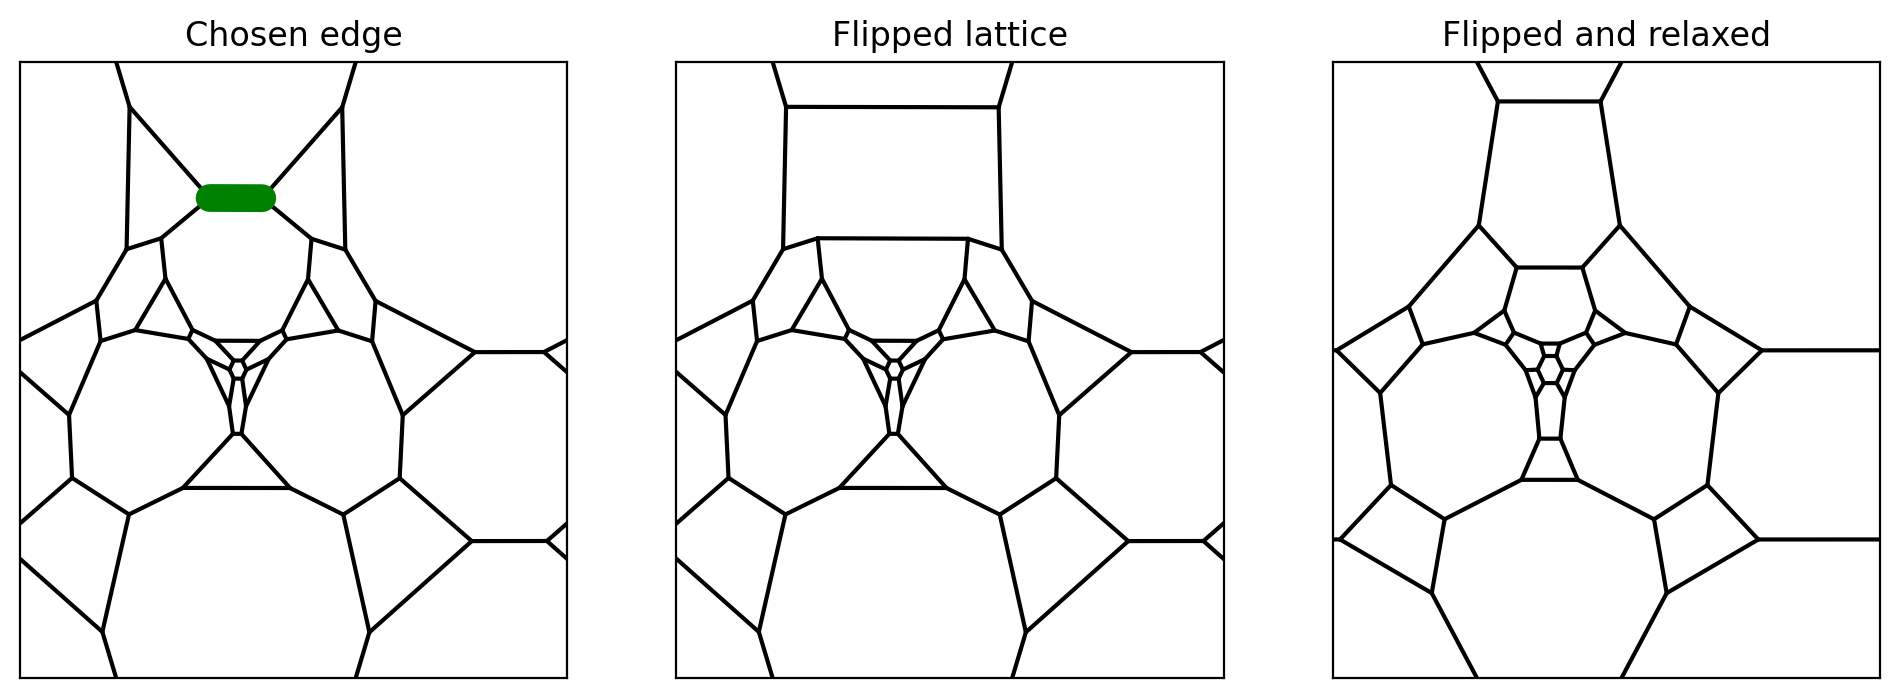

In [47]:
from koala.pachner_moves import bipartite_1_minus

# find a non-square:
e = 6
# l1minus = bipartite_1_minus(lattice, 21)

fig, ax = plt.subplots(1, 3, figsize=(12, 4), dpi=200)
for a in ax:
    a.set_xticks([])
    a.set_yticks([])

labels = np.zeros(lattice.n_edges)
labels[e] = 1
pl.plot_edges(lattice, ax=ax[0])
pl.plot_edges(
    lattice,
    subset=[e],
    labels=labels,
    color_scheme=["k", "g"],
    ax=ax[0],
    linewidth=10,
    zorder=10,
)

l1minus = bipartite_1_minus(lattice, e)

pl.plot_edges(l1minus, ax=ax[1])
pl.plot_edges(gu.com_relaxation(l1minus), ax=ax[2])

ax[0].set_title("Chosen edge")
ax[1].set_title("Flipped lattice")
ax[2].set_title("Flipped and relaxed")

In [48]:
# from koala.pachner_moves import bipartite_2_plus

# e = 6
# labels = np.zeros(lattice.n_edges)
# labels[e] = 1
# l2plus = bipartite_2_plus(lattice, e)


# fig, ax = plt.subplots(1, 3, figsize=(12, 4), dpi=200)
# for a in ax:
#     a.set_xticks([])
#     a.set_yticks([])

# pl.plot_edges(lattice, ax=ax[0])
# pl.plot_edges(
#     lattice,
#     subset=[e],
#     labels=labels,
#     color_scheme=["k", "g"],
#     ax=ax[0],
#     linewidth=10,
#     zorder=10,
# )


# ax[0].set_title("Chosen plaquette and vertex")
# ax[1].set_title("Flipped lattice")
# ax[2].set_title("Flipped and relaxed")
# plt.show()